# ARTI308 - Machine Learning Lab 3

### 1. Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("coffee_sales.csv")

 ### 2. Display first 5 rows

In [2]:
df.head()

,date,datetime,cash_type,money,coffee_name
0,2025-02-08,2025-02-08 14:26:04,cash,15.0,Tea
1,2025-02-08,2025-02-08 14:28:26,cash,15.0,Tea
2,2025-02-08,2025-02-08 14:33:04,card,20.0,Espresso
3,2025-02-08,2025-02-08 15:51:04,card,30.0,Chocolate with coffee
4,2025-02-08,2025-02-08 16:35:01,cash,27.0,Chocolate with milk


### 3. Check Missing Values

In [3]:
print(df.isna())

      date  datetime  cash_type  money  coffee_name
0    False     False      False  False        False
1    False     False      False  False        False
2    False     False      False  False        False
3    False     False      False  False        False
4    False     False      False  False        False
..     ...       ...        ...    ...          ...
257  False     False      False  False        False
258  False     False      False  False        False
259  False     False      False  False        False
260  False     False      False  False        False
261  False     False      False  False        False

[262 rows x 5 columns]


In [4]:
print(df.isna().sum())

date           0
datetime       0
cash_type      0
money          0
coffee_name    0
dtype: int64


### 4. Check duplicate rows

In [5]:
df.duplicated()[df.duplicated()==True]

111    True
256    True
dtype: bool

### 5. Number of rows and columns

In [6]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (262, 5) 

number of rows:  262
number of columns:  5


### 6. Data type of columns

In [7]:
df.dtypes

date               str
datetime           str
cash_type          str
money          float64
coffee_name        str
dtype: object

In [8]:
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

df.dtypes

date           datetime64[us]
datetime       datetime64[us]
cash_type                 str
money                 float64
coffee_name               str
dtype: object

### 7. Descriptive summary Statistics

In [9]:
df.describe(include='all')

,date,datetime,cash_type,money,coffee_name
count,262,262,262,262.00000,262
unique,NaN,NaN,2,NaN,30
top,NaN,NaN,card,NaN,Americano with milk
freq,NaN,NaN,182,NaN,44
mean,2025-02-28 15:01:22.442748,2025-03-01 06:16:04.549618,NaN,26.29771,NaN
min,2025-02-08 00:00:00,2025-02-08 14:26:04,NaN,15.00000,NaN
25%,2025-02-17 06:00:00,2025-02-18 01:05:45.750000,NaN,25.00000,NaN
50%,2025-02-28 00:00:00,2025-02-28 13:21:28.500000,NaN,27.00000,NaN
75%,2025-03-12 00:00:00,2025-03-12 14:52:39.500000,NaN,29.00000,NaN
max,2025-03-23 00:00:00,2025-03-23 21:23:11,NaN,33.00000,NaN


### 8. Univariate Analysis

#### Distribution of Coffee Sales Amount

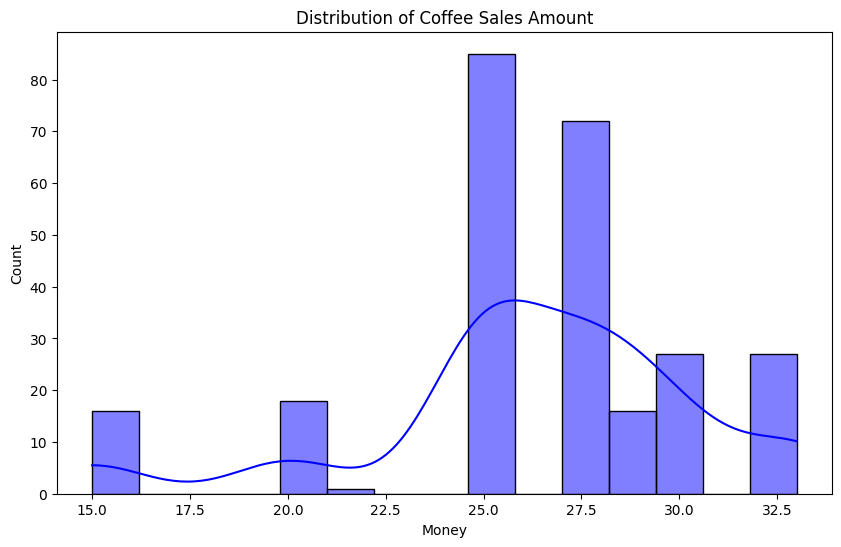

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['money'], kde=True, color='blue')
plt.title('Distribution of Coffee Sales Amount')
plt.xlabel('Money')
plt.show()

#### Frequency of Coffee Types Sold

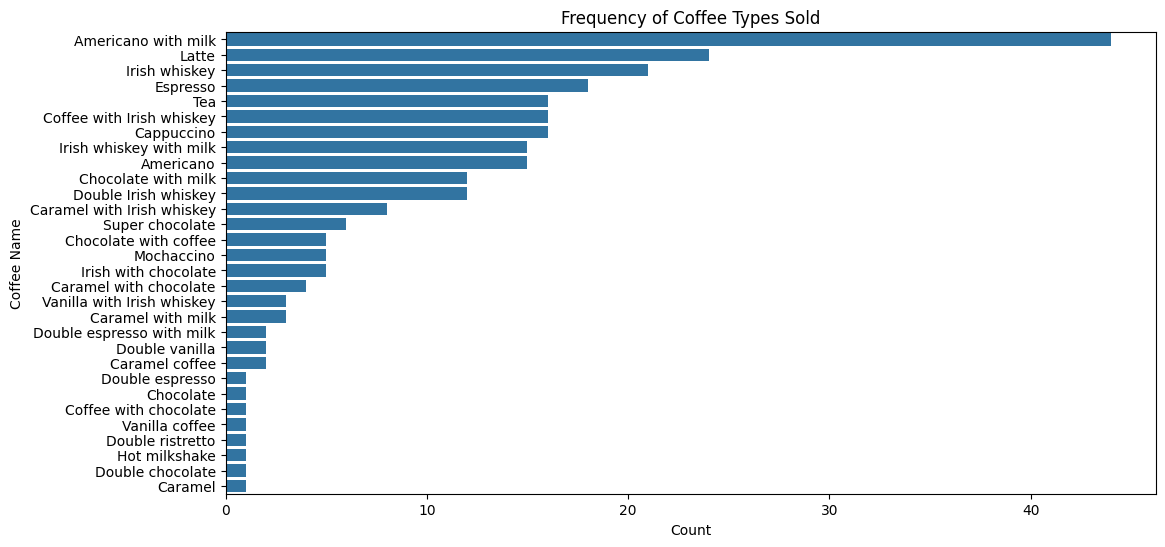

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(y='coffee_name', data=df, order=df['coffee_name'].value_counts().index)
plt.title('Frequency of Coffee Types Sold')
plt.ylabel('Coffee Name')
plt.xlabel("Count")
plt.show()

### 9. Bivariate Analysis

#### Sales Amount by Payment Type

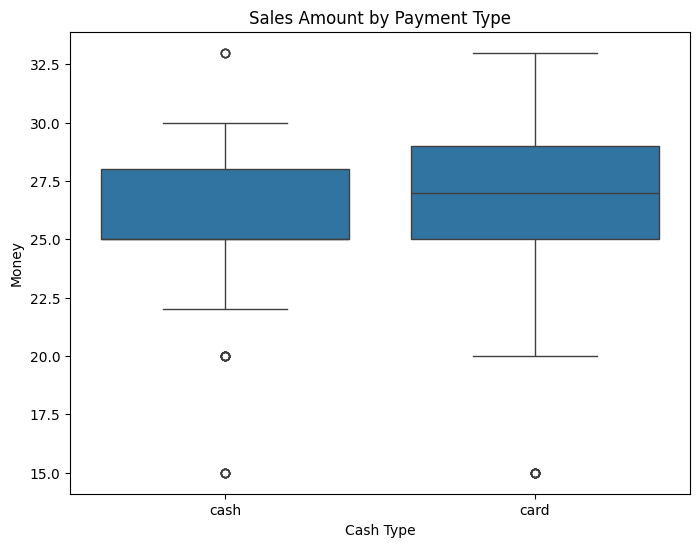

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='cash_type', y='money', data=df)
plt.title('Sales Amount by Payment Type')
plt.ylabel('Money')
plt.xlabel("Cash Type")
plt.show()

### 10. Time-Based Analysis

#### Total Revenue by Hour of Day

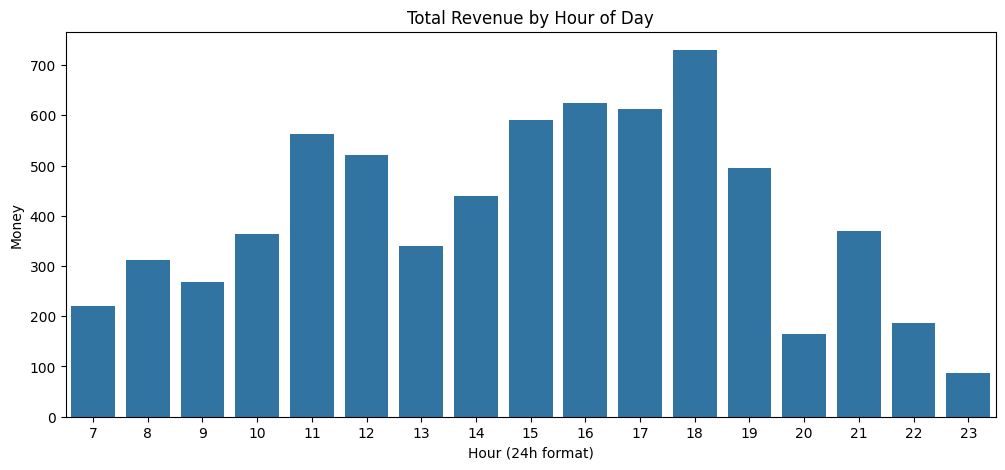

In [13]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

plt.figure(figsize=(12,5))
sns.barplot(x='hour', y='money', data=df, estimator=sum, errorbar=None)
plt.title("Total Revenue by Hour of Day")
plt.ylabel('Money')
plt.xlabel("Hour (24h format)")
plt.show()